In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib
import seaborn as sns 
import numpy as np 
cmap = ['#AEACAB','black']

In [4]:
def std_err(arr):
    err = np.nanstd(arr,axis=0)/np.sqrt(np.sum(~np.isnan(arr),axis=0))
    return err

def pval_to_asterisks(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# from scipy.stats import dunnett, kruskal, wilcoxon
# def stat(vals):
#     kru = kruskal(vals)
#     kru_p = kru.pvalue
#     dunnett()

In [6]:
fpath = '/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure7/TPN1_FMIN_silencing_each_part_body/data/TPN1_FMIN_inhibition_251228_labial.xlsx'
sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df_all = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df_all[s] = df
data_df_all

{'retinal -':    SS48944>GtACR1 whole body   SS48944>GtACR1 head  SS48944>GtACR1 lower body  \
 0                         0.9                  0.5                        0.9   
 1                         0.8                  1.0                        0.5   
 2                         0.5                  0.5                        0.9   
 3                         0.6                  0.6                        0.8   
 4                         0.7                  0.9                        0.4   
 5                         0.8                  0.7                        0.7   
 
    R30A08>GtACR1  whole body   
 0                         0.6  
 1                         0.8  
 2                         0.7  
 3                         1.0  
 4                         0.5  
 5                         0.7  ,
 'retinal +':    SS48944>GtACR1 whole body   SS48944>GtACR1 head  SS48944>GtACR1 lower body  \
 0                         0.4                  0.2                        0.8   
 1

((-0.05, 0.5), (-0.05, 0.6), (-0.05, 0.7), (-0.03333333333333333, 0.8), (-0.06666666666666667, 0.8), (-0.05, 0.9))
((0.05, 0.1), (0.05, 0.2), (0.05, 0.3), (0.05, 0.4), (0.03333333333333333, 0.5), (0.06666666666666667, 0.5))
((0.26666666666666666, 0.5), (0.23333333333333334, 0.5), (0.25, 0.6), (0.25, 0.7), (0.25, 0.9), (0.25, 1.0))
((0.35, 0.1), (0.3333333333333333, 0.2), (0.36666666666666664, 0.2), (0.35, 0.5), (0.3333333333333333, 0.6), (0.36666666666666664, 0.6))
((0.5499999999999999, 0.4), (0.5499999999999999, 0.5), (0.5499999999999999, 0.7), (0.5499999999999999, 0.8), (0.5666666666666667, 0.9), (0.5333333333333333, 0.9))
((0.65, 0.4), (0.65, 0.5), (0.65, 0.6), (0.6333333333333333, 0.8), (0.6666666666666666, 0.8), (0.65, 0.9))
((0.8499999999999999, 0.5), (0.8499999999999999, 0.6), (0.8666666666666666, 0.7), (0.8333333333333333, 0.7), (0.8499999999999999, 0.8), (0.8499999999999999, 1.0))
((0.95, 0.4), (0.95, 0.6), (0.9333333333333332, 0.7), (0.9666666666666666, 0.7), (0.95, 0.8), (0.

/home/se/anaconda3/envs/flywire/lib/python3.9/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' n

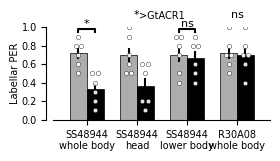

In [12]:
from scipy.stats import wilcoxon
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

fontsize = 7
# xfontsize = rotated_fontsize(fontsize,45)
lp=1
cmap = ['#AEACAB','black']

fig,ax = plt.subplots(1,1,figsize=(2.8,1.2))

    
df = data_df_all['retinal -']
mean_mat = pd.DataFrame(index=df.columns,columns=['retinal -','retinal +'])
std_mat = pd.DataFrame(index=df.columns,columns=['retinal -','retinal +'])
for condition,df in data_df_all.items():    
    mean_mat[condition] = df.mean(axis=0)
    std_mat[condition] = std_err(df)
    
    
# mean_mat = pd.concat((mean_mat,mean_mat_inter.loc[['SS48944 FMIn','SS48949 FMIn']]))
# std_mat = pd.concat((std_mat,std_mat_inter.loc[['SS48944 FMIn','SS48949 FMIn']]))
    
bar_spacing = .3
num_bars = len(mean_mat)
x_loc = np.arange(0, num_bars * bar_spacing, bar_spacing)  
bar_width = .1


# 그룹 막대 그리기
ax.bar(x_loc[:2] - bar_width / 2, mean_mat['retinal -'][:2], yerr=std_mat['retinal -'][:2], width=bar_width, label='retinal -', color=cmap[0],edgecolor='black',lw=.5)
ax.bar(x_loc[2:] - bar_width / 2, mean_mat['retinal -'][2:], yerr=std_mat['retinal -'][2:], width=bar_width, label='retinal -', color=cmap[0],edgecolor='black',lw=.5)

ax.bar(x_loc[:2] + bar_width / 2, mean_mat['retinal +'][:2], yerr=std_mat['retinal +'][:2], width=bar_width, label='retinal +', color=cmap[1],edgecolor='black',lw=.5)
ax.bar(x_loc[2:] + bar_width / 2, mean_mat['retinal +'][2:], yerr=std_mat['retinal +'][2:], width=bar_width, label='retinal +', color=cmap[1],edgecolor='black',lw=.5)

# ax.legend(['>UAS-Kir2.1','>lexAop-Kir2.1','>UAS-Kir2.1','>lexAop-Kir2.1'],ncol=2,fontsize=fontsize)

rows = []
df = data_df_all['retinal -']
for j in df.columns:
    rows += [{'group': 'retinal -', 'condition': j, 'value': v} for v in data_df_all['retinal -'][j]]
    rows += [{'group': 'retinal +', 'condition': j, 'value': v} for v in data_df_all['retinal +'][j]]
    


for i, cond in enumerate(mean_mat.index):
    x_base = x_loc[i]
    for group_idx, group in enumerate(['retinal -', 'retinal +']):
        values = np.array(data_df_all[group][cond])
        values = values[~np.isnan(values)]
       
        x_loc_per_v = {}
        x_jittered=[]
        v_unique,v_counts = np.unique(values,return_counts=True)
        for v in v_unique:
            n = v_counts[v_unique==v][0]
            step = bar_width/(n+1)
            direction = (-1)**(group_idx+1)
            for s in range(1,n+1):
                x_jittered.append(x_base + direction*step*s)
        values_resorted = np.concatenate([np.repeat(x,c) for x,c in zip(v_unique,v_counts)])
        print(tuple(zip(x_jittered,values_resorted)))
        
        ax.scatter(
            x_jittered,
            values_resorted,
            color='white',#colors[group_idx],
            edgecolor='black',
            linewidth=0.3,
            s=10,
            zorder=10,
            alpha=0.9
        )


        
# statistical test



cols = list(data_df_all['retinal -'].columns.values)
max_vals = np.nanmax(data_df_all['retinal -'].values,axis=0)
for i,c in enumerate(cols):
    _,pval = wilcoxon(data_df_all['retinal -'][c].dropna(),data_df_all['retinal +'][c].dropna(),alternative='greater',zero_method='pratt',method='approx')
    x1 = x_loc[cols.index(c)]-bar_width/2
    x2 = x_loc[cols.index(c)]+bar_width/2
    y = max_vals[i]+.05
    h=.03
    plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], c='k')
    plt.text((x1+x2)*.5, y+h, pval_to_asterisks(pval), ha='center', va='bottom', color='k',fontsize=8)         
        

# xlabel = ['+','R30A08-GAL4\nTPN1','SS48944-splitGAL4\nFMin','SS48949-splitGAL4\nFMin','+','R30A08-lexA\nTPN1']
# xlabel = ['lexAop-Kir2.1/+','R30A08-lexA>lexAop-Kir2.1','UAS-Kir2.1/+','R30A08-GAL4>UAS-Kir2.1','SS48944>Kir2.1','SS48949>Kir2.1']
xlabel = ['SS48944\nwhole body','SS48944\nhead','SS48944\nlower body','R30A08\nwhole body']

# xlabel = ["\n".join([x.split(" ")[-1],x.split(" ")[0]]) for x in mean_mat.index.values]
# xlabel[0] = 'control'
ax.set_xticks(x_loc,xlabel,fontsize=fontsize,rotation=0)
ax.set_yticks(list(np.arange(0,1.1,.2)),np.round(list(np.arange(0,1.1,.2)),2),fontsize=fontsize)
ax.set_ylabel('Labellar PER',fontsize=fontsize,labelpad=lp)
# ax.set_xlabel('experiment condition',fontsize=fontsize,labelpad=lp)
ax.set_ylim([0,1.1])
ax.spines[['top','right']].set_visible(False)
# ax.set_title('tarsal',fontsize=fontsize)
ax.set_xlim(-bar_spacing+bar_spacing/2, num_bars*bar_spacing-bar_spacing/2)
# plt.setp(ax.get_xticklabels(), rotation=0, ha='right')
ax.set_title('>GtACR1',fontsize=fontsize)
ax.spines['left'].set_position(('outward', 5))
ax.set_ylim([0,1])

import os 
margin = 0.2
ax.set_xlim(-margin, (num_bars - 1) * bar_spacing + margin)
plt.savefig(f'figures/TPN1_silencing_labial.svg')




In [11]:
pwd

'/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure7/TPN1_FMIN_silencing_each_part_body'